In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import ast

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

#convert skill list column into a list
def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)  
    return skill_list  # Return the original NaN value

df['job_skills'] = df['job_skills'].apply(clean_list)

c:\Users\Greg\anaconda3\envs\Python_Data_Project_1_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


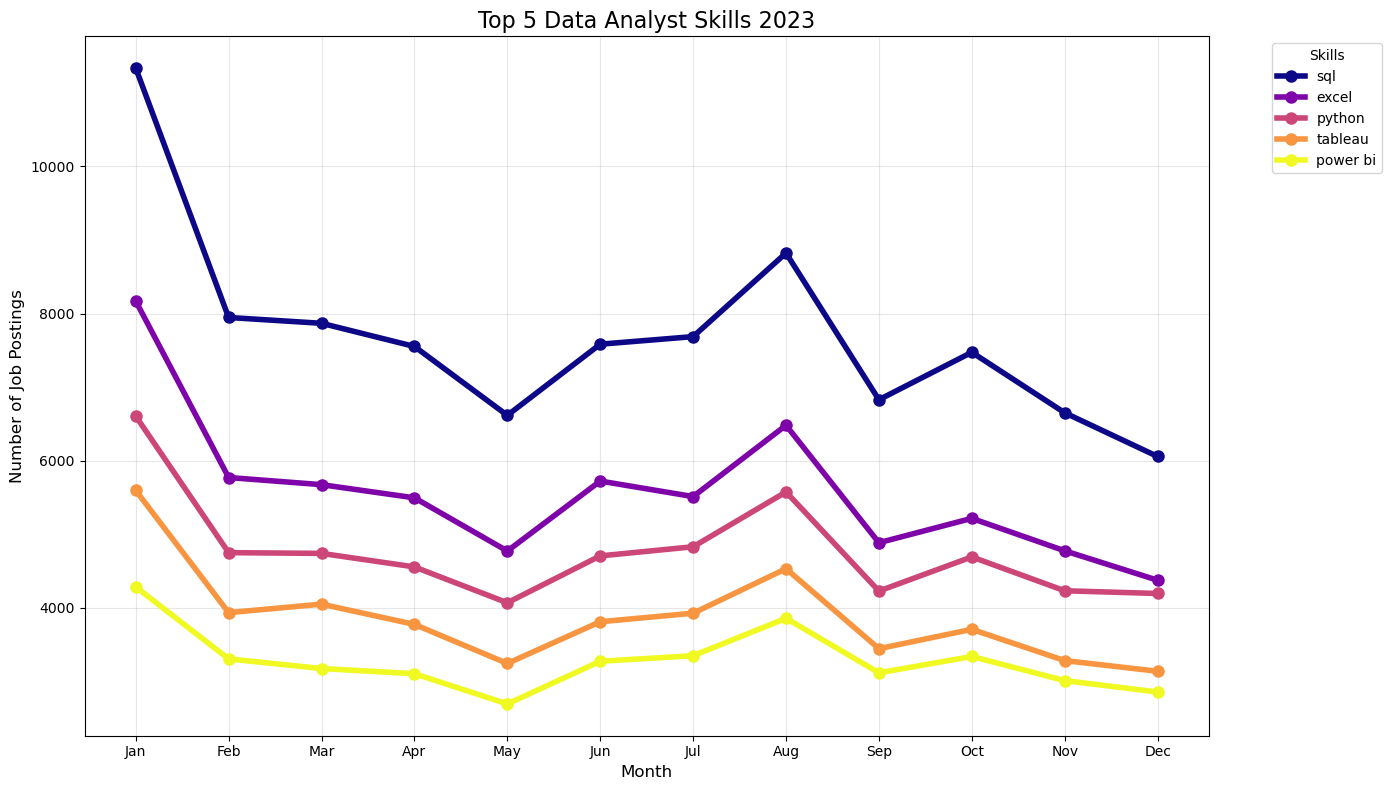

In [2]:
#ORGANIZE DATA ANALYST INFORMATION
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month
df_DA_exploded = df_DA.explode('job_skills')
df_DA_pivot = df_DA_exploded.pivot_table(
    index='job_posted_month_no', 
    columns='job_skills', 
    aggfunc='size',
    fill_value=0 )#fills the NaN values with zero

#we need to create a row called total that sums up the values in the newly created pivot columns
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot.loc['Total'].sort_values(ascending=False).index

df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_pivot = df_DA_pivot.drop('Total')

# Make sure index is integer and sorted
# Incorporating linewidth, colormap, markers and markersize
df_DA_pivot.index = df_DA_pivot.index.astype(int)
df_DA_pivot = df_DA_pivot.sort_index()

df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=4,
    colormap='plasma', 
    marker='o',
    markersize=8, 
    figsize=(14, 8)) #width and height
plt.title('Top 5 Data Analyst Skills 2023', fontsize=16)
plt.ylabel('Number of Job Postings', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Skills', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Customizing the scatter plot

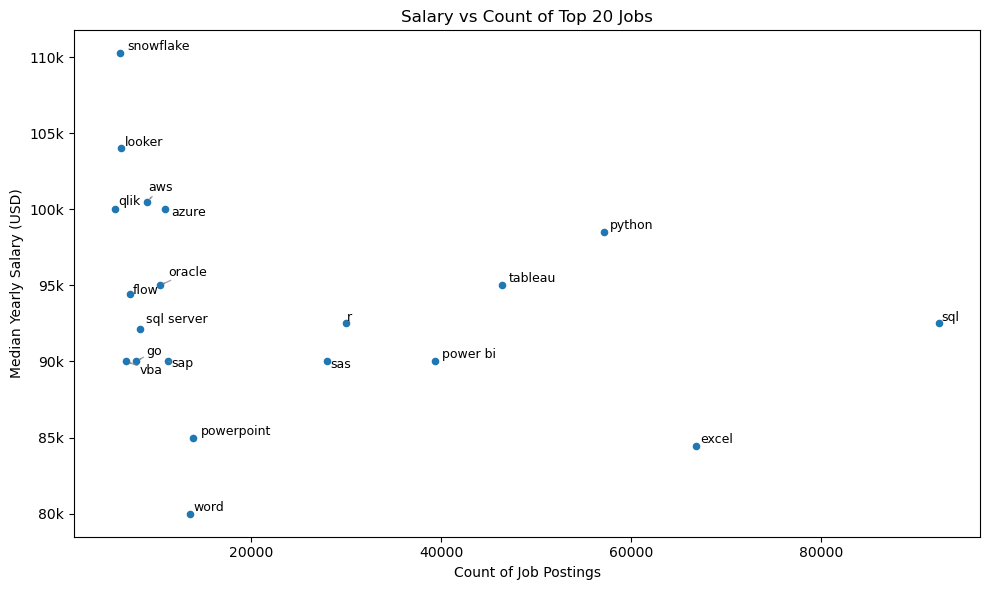

In [6]:
# Working with our previous job skills dataframe

from adjustText import adjust_text
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df = df[df['job_title_short'] == 'Data Analyst']

df_exploded = df.explode('job_skills')

# Using a tuple within the agg function
skills_stats = df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_salary = ('salary_year_avg', 'median')
)
skills_stats = skills_stats.sort_values(by='skill_count', ascending=False).head(20)

# plotting
ax = skills_stats.plot(kind='scatter', x='skill_count', y='median_salary', figsize=(10, 6))
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary (USD)')
plt.title('Salary vs Count of Top 20 Jobs')

# Format y-axis with FuncFormatter (show as 20k, 30k, 100k, etc.)
def format_salary(x, pos):
    return f'{x/1000:.0f}k'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_salary))

# Label data points using pyplot text
texts = []
for i, skill in enumerate(skills_stats.index):
    texts.append(plt.text(skills_stats['skill_count'].iloc[i],
             skills_stats['median_salary'].iloc[i], 
             skill, 
             fontsize=9))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1, alpha=0.7))

plt.tight_layout()
plt.show()